# Phase 1 : Data Understanding and Preprocessing


## EDA

### Importing libraries and loading dataset

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
df = pd.read_csv('churn.csv')

### Data Types and Missing Values

In [105]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [106]:
# missing value
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [107]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Check unique values for object data

In [108]:
print( "Surname Unique counts:", df['Surname'].value_counts())


Surname Unique counts: Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64


In [109]:
print("Geography Unique counts:", df['Geography'].value_counts())

Geography Unique counts: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [110]:
print("Gender counts:", df['Gender'].value_counts())

Gender counts: Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Outlier detection

In [111]:
# lihat outlier numerik pake IQR method

numeric_cols = df.select_dtypes(include=['number']).columns
cols_to_check = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId']]

def detect_outliers_iqr(data, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"Column: {col} | Outliers detected: {len(outliers)}")
        
    return list(set(outlier_indices))

outlier_list = detect_outliers_iqr(df, cols_to_check)

outlier_df = df.loc[outlier_list]


Column: CreditScore | Outliers detected: 15
Column: Age | Outliers detected: 359
Column: Tenure | Outliers detected: 0
Column: Balance | Outliers detected: 0
Column: NumOfProducts | Outliers detected: 60
Column: HasCrCard | Outliers detected: 0
Column: IsActiveMember | Outliers detected: 0
Column: EstimatedSalary | Outliers detected: 0
Column: Exited | Outliers detected: 2037


### Graph Distribution of numerical features

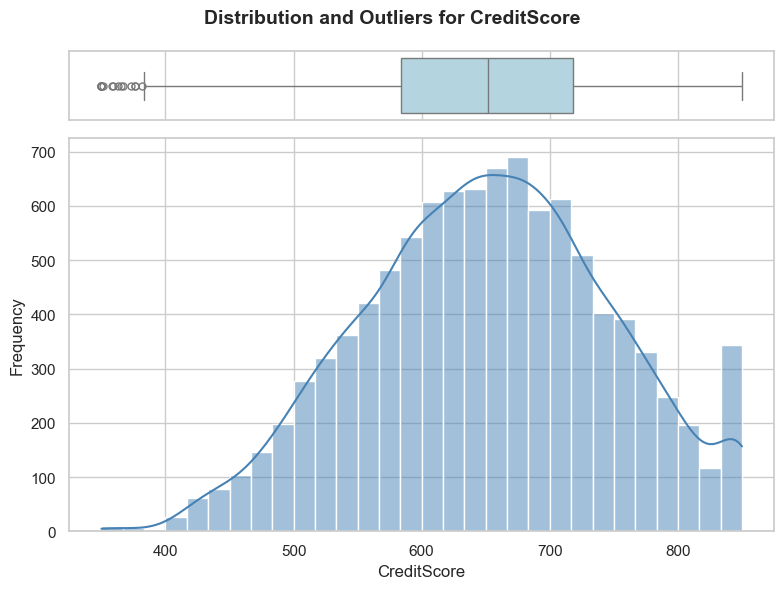

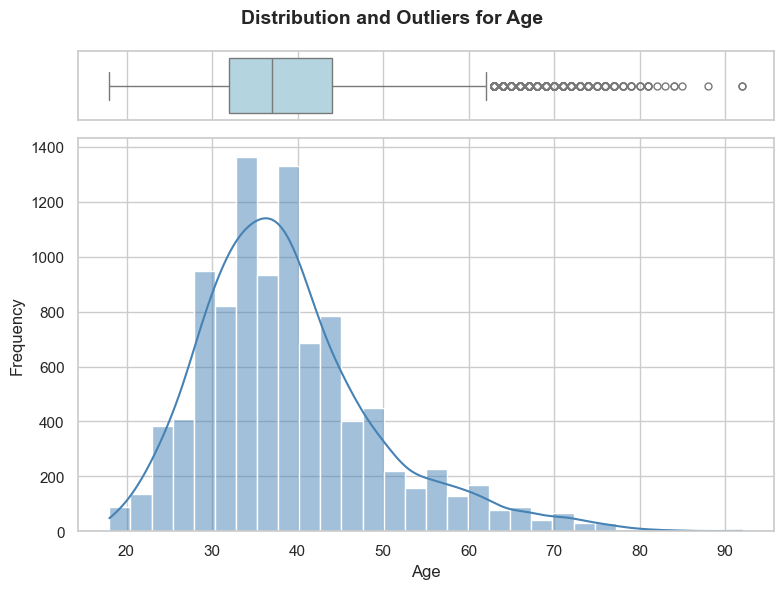

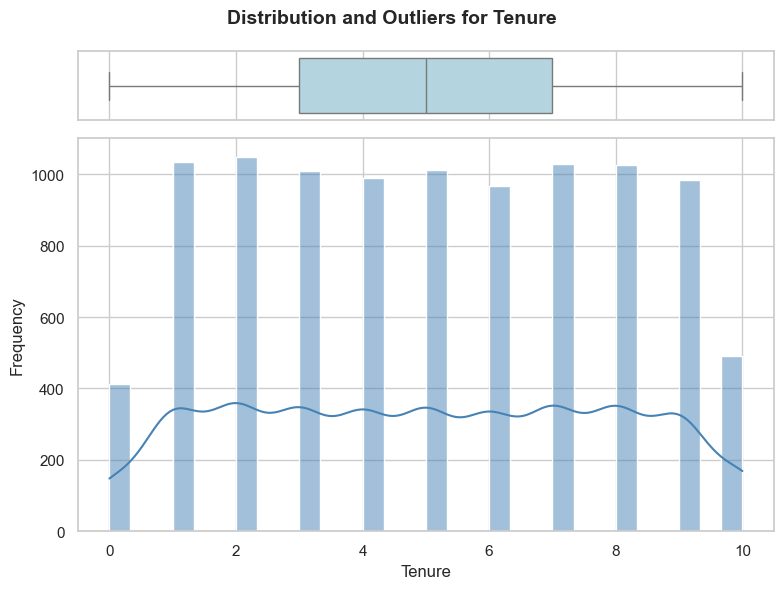

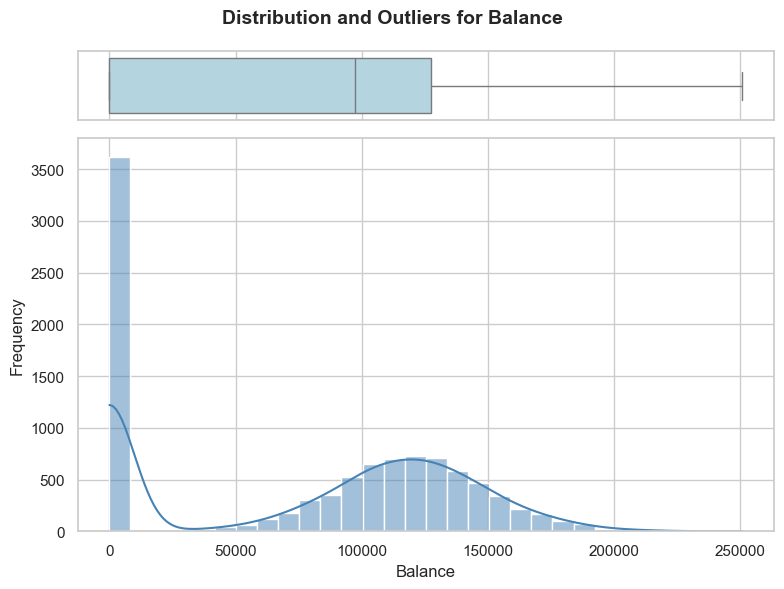

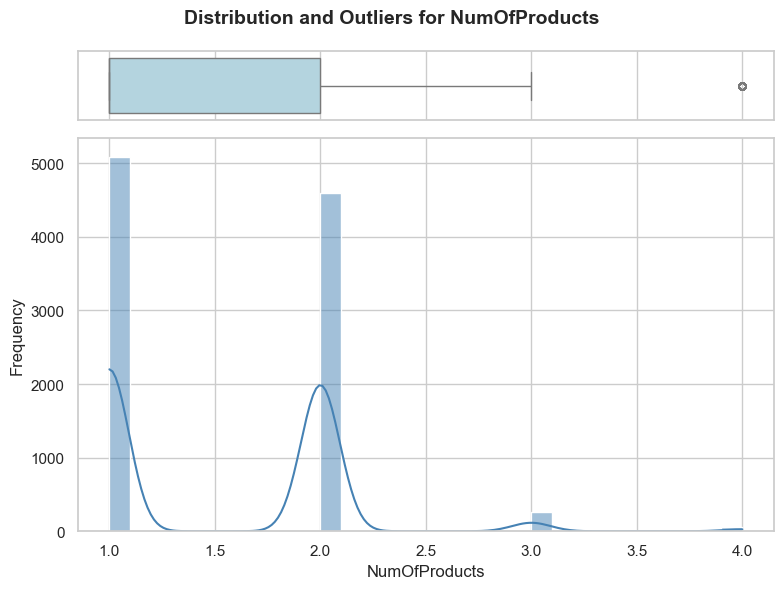

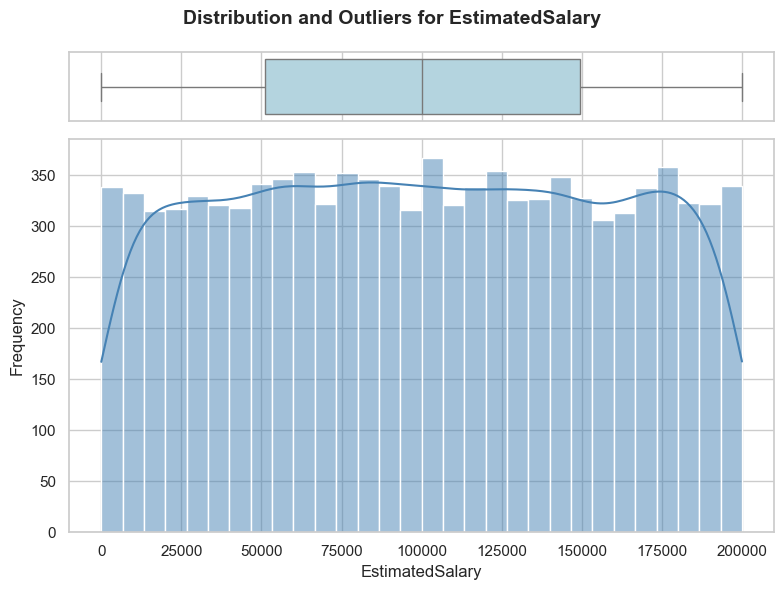

In [112]:
# plotbox distribution graph
# 1. Define your numerical columns (excluding IDs and binary flags)
cols_to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each column and create a combined graph
for col in cols_to_check:
    # Create a figure with 2 subplots: a small one on top for the boxplot, a larger one for the histogram
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    # Top graph: Boxplot (Visualizes the IQR and outliers)
    sns.boxplot(x=df[col], ax=ax_box, color='lightblue', flierprops=dict(marker='o', color='red', markersize=5))
    
    # Bottom graph: Histogram with KDE (Visualizes the distribution shape)
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color='steelblue', bins=30)
    
    # Clean up labels and layout
    ax_box.set(xlabel='') # Hide the x-axis label on the top plot
    ax_hist.set(xlabel=col, ylabel='Frequency')
    
    plt.suptitle(f'Distribution and Outliers for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Display or save the plot
    plt.show()
    # plt.savefig(f"{col}_distribution.png") # Uncomment this line to save the images to your computer

### Graph Count of object features

C:\Users\Thomas\AppData\Local\Temp\ipykernel_151040\1503290909.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


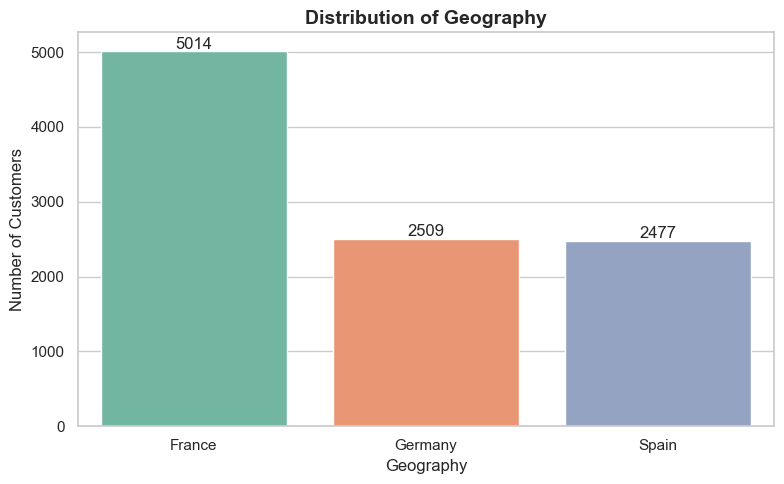

C:\Users\Thomas\AppData\Local\Temp\ipykernel_151040\1503290909.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


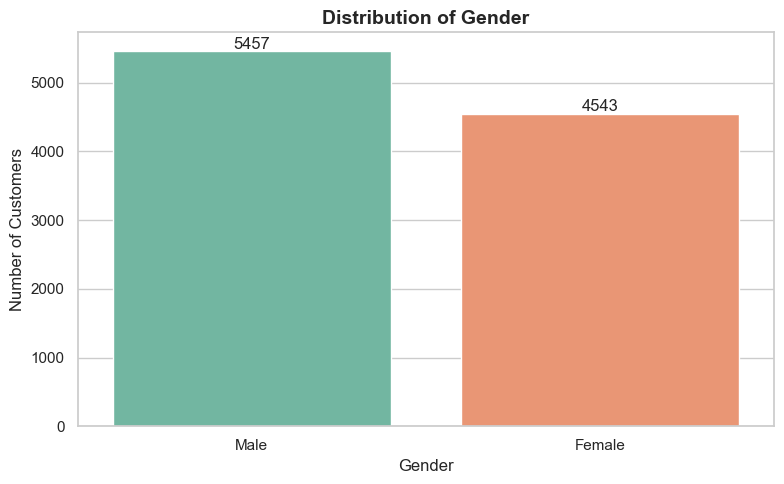

In [113]:
# 1. Identify object (categorical) columns
object_cols = df.select_dtypes(include=['object']).columns

# 2. Exclude IDs and high-cardinality columns like 'Surname'
# (Adjust this list if you have other specific text columns to ignore)
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname']
cols_to_plot = [col for col in object_cols if col not in cols_to_exclude]

# 3. Set the visual style
sns.set_theme(style="whitegrid")

# 4. Loop through each categorical column and create a bar chart
for col in cols_to_plot:
    plt.figure(figsize=(8, 5))
    
    # Create a count plot (bar chart counting occurrences)
    ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    
    # Add titles and labels
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    # Add data labels on top of each bar for clarity
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Apply data cleaning

In [114]:
# Remove duplicates
print("Duplicates before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()

# Handle missing values (doesnt exist in this dataset but good to check)
print("Missing values before cleaning:\n", df.isna().sum())
# Drop rows with missing values as a basic approach (Alternatively, imputation could be used for ETL pipelines)
df = df.dropna()

# Drop irrelevant columns (Noise Handling & Attribute Types)
# RowNumber, CustomerId, and Surname do not carry predictive power for churn and act as noise.
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("Shape after data cleaning:", df.shape)

Duplicates before cleaning: 0
Missing values before cleaning:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Shape after data cleaning: (10000, 11)


In [115]:
zero_age_count = (df['Age'] == 0).sum()
print(f"Number of customers with Age 0: {zero_age_count}")

Number of customers with Age 0: 0


## Perform data transformation: normalization, encoding, and binning of continuous variables

In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder


# Create the Age bin, but keep the original Age column
if 'Age' in df.columns:
    # Changed to include_lowest=True and extended bins so no ages fall out-of-bounds (causing NaNs)
    df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 50, 60, 150], labels=[0, 1, 2, 3]).astype(int)

# --- 2. TRAIN-TEST SPLIT ---
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. DEFINE PIPELINE TRANSFORMERS ---
# Group your columns by how they need to be treated
numeric_cols = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'Age']
categorical_cols = ['Geography']
binary_cols = ['Gender']

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Scale continuous variables ignoring outliers
        ('num', RobustScaler(), numeric_cols), 
        
        # One-Hot Encode Geography, dropping the first to avoid multicollinearity
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols), 
        
        # Ordinal Encode Gender (Transforms Female/Male to 0/1 automatically)
        ('bin', OrdinalEncoder(), binary_cols) 
    ],
    # 'passthrough' tells the pipeline to ignore columns we didn't specify (like AgeGroup) 
    # instead of accidentally deleting them.
    remainder='passthrough' 
)

# --- 4. ASSEMBLE THE PIPELINE ---
# Right now it just preprocesses, but you will add your ML model here in the next phase!
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
    # Future step: ('classifier', XGBClassifier())
])

# --- 5. EXECUTE ---
# Fit and transform the training data
# (If you need it back as a Pandas DataFrame for your report, wrap it like this):
X_train_clean = pd.DataFrame(
    pipeline.fit_transform(X_train), 
    columns=pipeline.get_feature_names_out()
)

# ONLY transform the test data
X_test_clean = pd.DataFrame(
    pipeline.transform(X_test), 
    columns=pipeline.get_feature_names_out()
)

print(X_train_clean.head())

   num__CreditScore  num__Balance  num__EstimatedSalary  num__Tenure  \
0          0.759398     -0.760422              0.613559          0.4   
1          0.654135      0.039748             -0.362501         -0.4   
2          0.774436      0.131706              0.183463         -1.0   
3         -0.684211     -0.760422             -0.167154          0.0   
4          0.300752      0.105657              0.082036          0.2   

   num__NumOfProducts  num__Age  cat__Geography_Germany  cat__Geography_Spain  \
0                 0.0  1.666667                     0.0                   0.0   
1                 0.0 -0.416667                     1.0                   0.0   
2                 1.0  0.000000                     1.0                   0.0   
3                 1.0  0.000000                     0.0                   0.0   
4                 1.0  1.000000                     1.0                   0.0   

   bin__Gender  remainder__HasCrCard  remainder__IsActiveMember  \
0          1.

## Conduct feature selection using correlation analysis and entropy measures

### Heatmap of correlation between numerical features and entropy

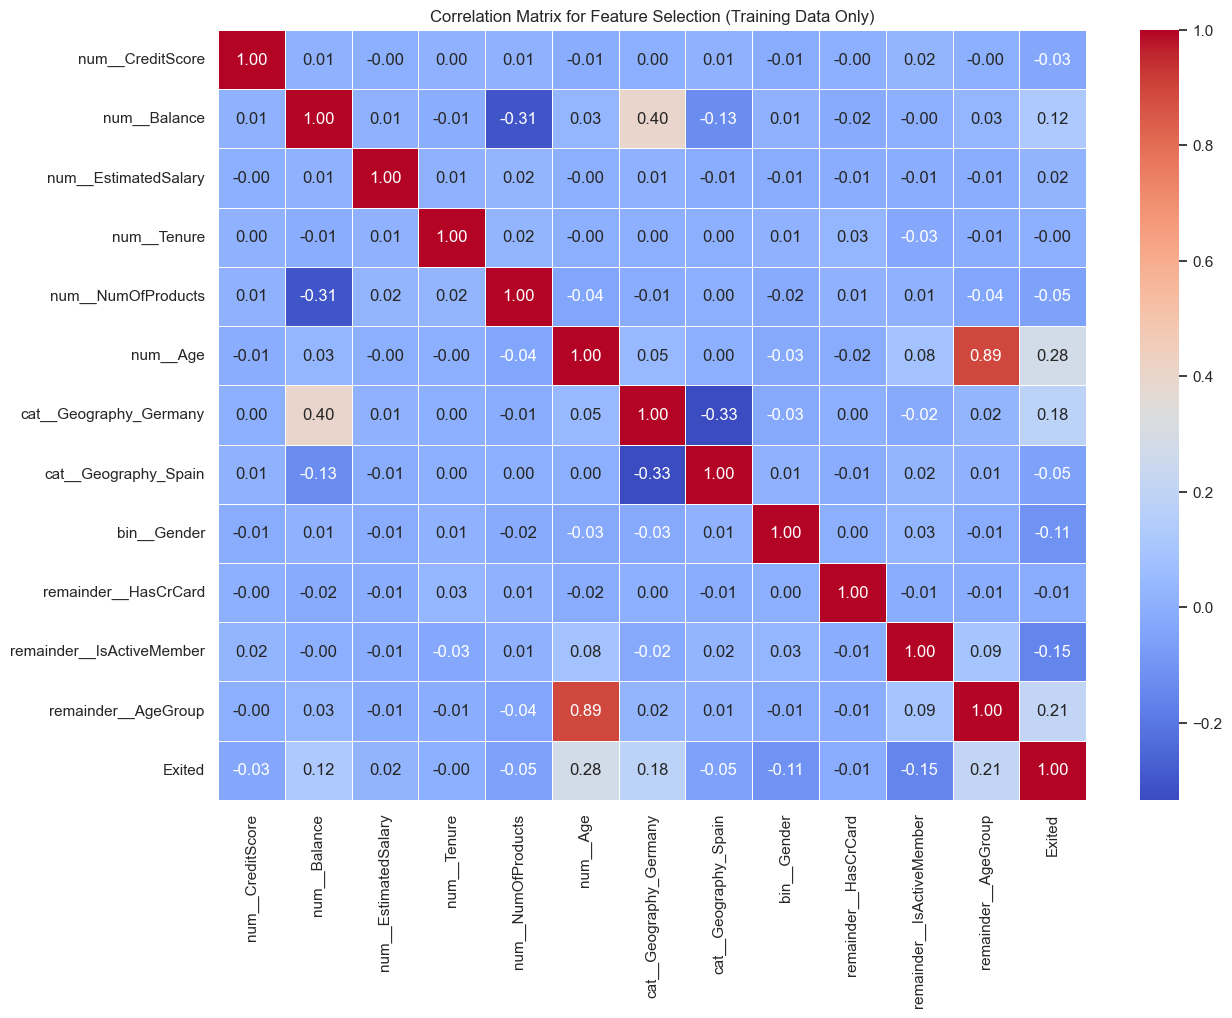


Features correlated with target ('Exited'):
 Exited                       1.000000
num__Age                     0.280378
remainder__AgeGroup          0.208462
cat__Geography_Germany       0.182234
remainder__IsActiveMember    0.152286
num__Balance                 0.121441
bin__Gender                  0.105920
num__NumOfProducts           0.054462
cat__Geography_Spain         0.054385
num__CreditScore             0.033998
num__EstimatedSalary         0.020260
remainder__HasCrCard         0.014524
num__Tenure                  0.002368
Name: Exited, dtype: float64

Entropy of Target Variable (Exited) in Training Data: 0.7294


In [118]:
import scipy.stats as ss
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a dedicated analysis DataFrame using ONLY the training data
analysis_df = X_train_clean.copy()
analysis_df['Exited'] = y_train.values # .values is critical here to align indices

# 2. Pearson Correlation (Linear ya, jangan terlalu dianggap valid banget)
plt.figure(figsize=(14, 10))
correlation_matrix = analysis_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Feature Selection (Training Data Only)")
plt.show()

# 3. Sort fitur yang paling berkorelasi dengan target 'Exited'
if 'Exited' in correlation_matrix.columns:
    # Notice we use the analysis_df correlation matrix here
    target_corr = correlation_matrix['Exited'].abs().sort_values(ascending=False)
    print("\nFeatures correlated with target ('Exited'):\n", target_corr)
    
# 4. Entropy
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts = True)
    entropy_val = np.sum([(-counts[i]/np.sum(counts))*np.log2(counts[i]/np.sum(counts)) for i in range(len(elements))])
    return entropy_val

# Notice we calculate entropy strictly on the training target variable
print(f"\nEntropy of Target Variable (Exited) in Training Data: {entropy(y_train):.4f}")

#### Checking for imbalanced in 'Exited' variable

In [119]:
# Check imbalance in Exited
df['Exited'].value_counts(normalize=True)

# 80-20 ratio, harus apply SMOTE / class weighting, isolation tree(?), ensemble method(?),
# anomaly detection, encoder(?)
# evaluation metrics yang sesuai (precision-recall, F1-score)


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## Deliverable: Clean dataset file and Preprocessing Report

In [120]:
# --- DELIVERABLE: SAVE THE CLEAN TARGET DATASETS ---

# Re-attach the target variable ('Exited') to the transformed features
train_clean = X_train_clean.copy()
train_clean['Exited'] = y_train.values  # .values ensures the index aligns

test_clean = X_test_clean.copy()
test_clean['Exited'] = y_test.values

# Define filenames
train_filename = 'churn_train_clean.csv'
test_filename = 'churn_test_clean.csv'

# Save to CSV without the index
train_clean.to_csv(train_filename, index=False)
test_clean.to_csv(test_filename, index=False)

print(f"Phase 1 execution complete.")
print(f"Training dataset saved to '{train_filename}'.")
print(f"Testing dataset saved to '{test_filename}'.")

Phase 1 execution complete.
Training dataset saved to 'churn_train_clean.csv'.
Testing dataset saved to 'churn_test_clean.csv'.


# Phase 2: Segmentation via Clustering

## Apply K-Means clustering to segment entities by behavioral or financial attributes

## Use DBSCAN to identify outlier profiles and noise points within the data

## Apply Hierarchical clustering and compare dendrograms across linkage methods

## Determine optimal K using the Elbow Method and Silhouette Score

## Profile each cluster: describe the entity type it represents and its distinguishing characteristics

## Deliverable: Cluster profiles with full business interpretation

# Phase 3: Association Rule Mining

# Phase 4: Anomaly and Outlier Detection

## Apply statistical methods (IQR, Z-score) to flag anomalous behaviors or values

## Use Isolation Forest as a structural anomaly discovery tool

## Cross-reference detected anomalies with cluster outliers from Phase 2

## Investigate each anomaly: data error, rare legitimate case, or potential risk signal?

## Deliverable: Anomaly report with flagged records, explanation, and business interpretation

## Discretize continuous variables into meaningful categorical groups

## Apply the Apriori algorithm to discover frequent itemsets across the dataset

## Generate association rules and compute Support, Confidence, and Lift for each

## Filter rules to retain only meaningful, non-trivial, high-lift findings

## Discover and document at least 10 rules with clear business interpretation

## Deliverable: Rule table with ranked rules and business commentary